In [1]:
!pip install pandas openpyxl

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# read file
df = pd.read_excel('/kaggle/input/employee-dat/Employee-turnover.xlsx', engine='openpyxl', header=1)

# **Data Exploration**

In [4]:
df.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19**,2019-20,2020-21
0,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of separating employees (excluding casu...,1518,1730,1899,2364,2170,1885,1854.000
1,"Creative industries, finance, transport and other",All employees (excluding casuals),Separation rate,0.108,0.115,0.123,0.139,0.144,0.121,0.113
2,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of commencing employees (excluding casu...,1553,2193,2364,3105,2600,2067,2604.000
3,"Creative industries, finance, transport and other",All employees (excluding casuals),New staff rate,0.11,0.146,0.153,0.183,0.173,0.133,0.159
4,Government schools,All employees (excluding casuals),Number of separating employees (excluding casu...,5790,6328,5428,6160,6808,6755,5653.000


In [5]:
# general info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  585 non-null    object 
 1   Group            582 non-null    object 
 2   Measure          582 non-null    object 
 3   2014-15          580 non-null    object 
 4   2015-16          580 non-null    object 
 5   2016-17          580 non-null    object 
 6   2017-18          580 non-null    object 
 7   2018-19**        580 non-null    object 
 8   2019-20          580 non-null    object 
 9   2020-21          582 non-null    float64
dtypes: float64(1), object(9)
memory usage: 45.8+ KB


# **Data Cleaning**

In [6]:
# drop empty rows
df = df.dropna(how='all')

df.columns = [col.strip() for col in df.columns]

df.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19**,2019-20,2020-21
0,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of separating employees (excluding casu...,1518,1730,1899,2364,2170,1885,1854.000
1,"Creative industries, finance, transport and other",All employees (excluding casuals),Separation rate,0.108,0.115,0.123,0.139,0.144,0.121,0.113
2,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of commencing employees (excluding casu...,1553,2193,2364,3105,2600,2067,2604.000
3,"Creative industries, finance, transport and other",All employees (excluding casuals),New staff rate,0.11,0.146,0.153,0.183,0.173,0.133,0.159
4,Government schools,All employees (excluding casuals),Number of separating employees (excluding casu...,5790,6328,5428,6160,6808,6755,5653.000


In [7]:
# column name with **
df.columns = [str(col).strip().replace('**', '') for col in df.columns]

In [8]:
# view columns
print([col for col in df.columns])

['Industry sector', 'Group', 'Measure', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21']


# **Data Exploration**

# Demand over time for All employees (excluding casuals)

In [9]:
# filter for commencing data across industries for all employees
commencing_df = df[
    (df['Measure'] == 'Number of commencing employees (excluding casuals)') &
    (df['Group'] == 'All employees (excluding casuals)')
]
commencing_df

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
2,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of commencing employees (excluding casu...,1553,2193,2364,3105,2600,2067,2604.0
6,Government schools,All employees (excluding casuals),Number of commencing employees (excluding casu...,6595,7623,6298,7632,6507,4824,5182.0
10,Police and emergency services,All employees (excluding casuals),Number of commencing employees (excluding casu...,1452,1586,1975,2476,2223,2104,1860.0
14,Public health care,All employees (excluding casuals),Number of commencing employees (excluding casu...,14920,15641,17475,18108,19340,18350,21698.0
18,TAFE and other education,All employees (excluding casuals),Number of commencing employees (excluding casu...,741,996,1081,1330,1980,1275,1330.0
22,Water and land management,All employees (excluding casuals),Number of commencing employees (excluding casu...,872,1036,996,1188,1342,1114,1657.0
26,Total public entities,All employees (excluding casuals),Number of commencing employees (excluding casu...,26133,29075,30189,33839,33992,29734,34331.0
30,Victorian Public Service,All employees (excluding casuals),Number of commencing employees (excluding casu...,5070,6084,8189,9225,10051,7956,15664.0
34,Overall public sector,All employees (excluding casuals),Number of commencing employees (excluding casu...,31203,35159,38378,43064,44043,37690,49995.0


In [10]:
commencing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 2 to 34
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  9 non-null      object 
 1   Group            9 non-null      object 
 2   Measure          9 non-null      object 
 3   2014-15          9 non-null      object 
 4   2015-16          9 non-null      object 
 5   2016-17          9 non-null      object 
 6   2017-18          9 non-null      object 
 7   2018-19          9 non-null      object 
 8   2019-20          9 non-null      object 
 9   2020-21          9 non-null      float64
dtypes: float64(1), object(9)
memory usage: 792.0+ bytes


In [11]:
# get unique years in data
print("Unique Industry sectors in data:")
commencing_df['Industry sector'].unique()

Unique Industry sectors in data:


array(['Creative industries, finance, transport and other',
       'Government schools', 'Police and emergency services',
       'Public health care', 'TAFE and other education',
       'Water and land management', 'Total public entities',
       'Victorian Public Service', 'Overall public sector'], dtype=object)

In [12]:
print("Count of Unique Industry sectors in data:")
len(commencing_df['Industry sector'].unique())

Count of Unique Industry sectors in data:


9

In [13]:
# year columns
year_cols = ['2014-15', '2015-16', '2016-17', '2017-18', '2018-19']

# Top Hiring Sectors according to Number of commencing employees 

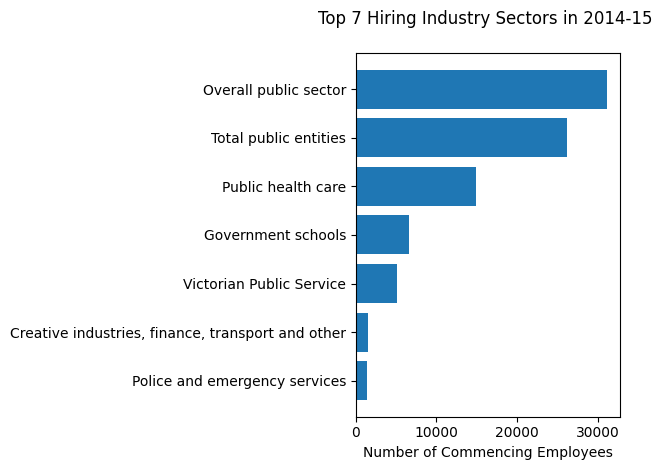

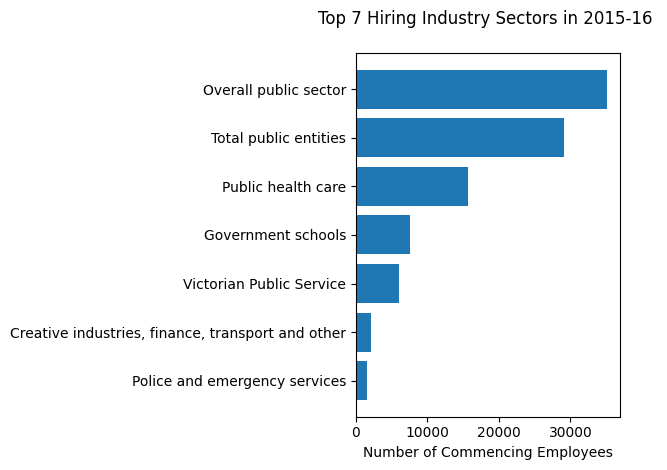

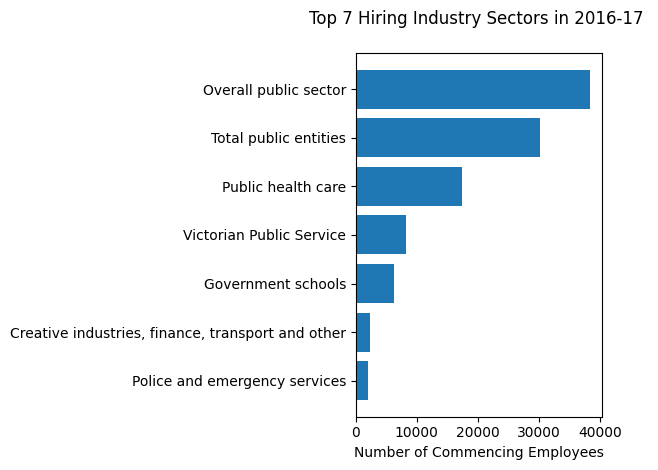

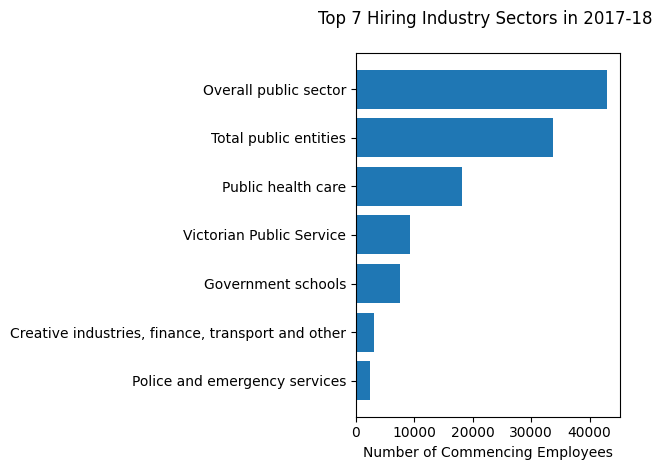

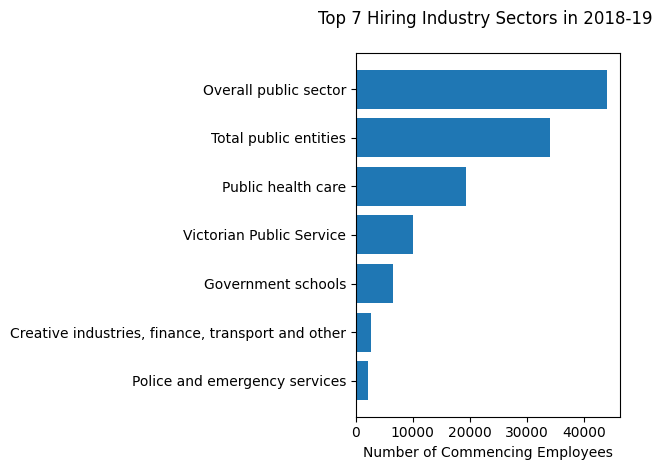

In [14]:
# get N top commencing sectors per year
N = 7
for year in year_cols:
    top_sectors = commencing_df[['Industry sector', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Industry sector'], top_sectors[year])
    plt.title(f"Top {N} Hiring Industry Sectors in {year} \n")
    plt.xlabel("Number of Commencing Employees")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Accross the years, the Overall public sector is the one with the most Number of commencing employees for All employees

# Bottom Hiring Sectors according to Number of commencing employees 

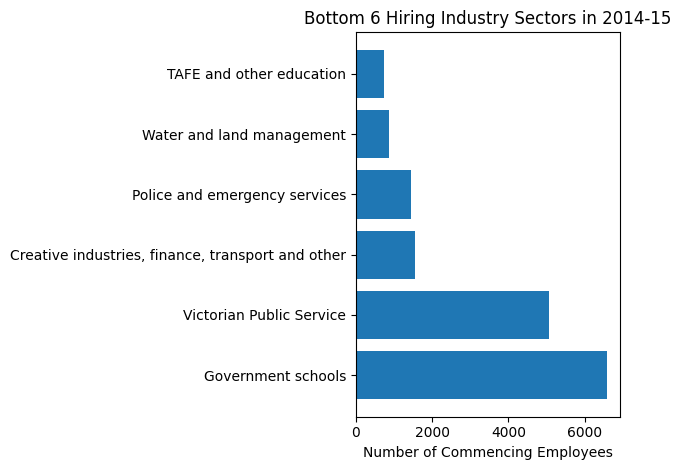

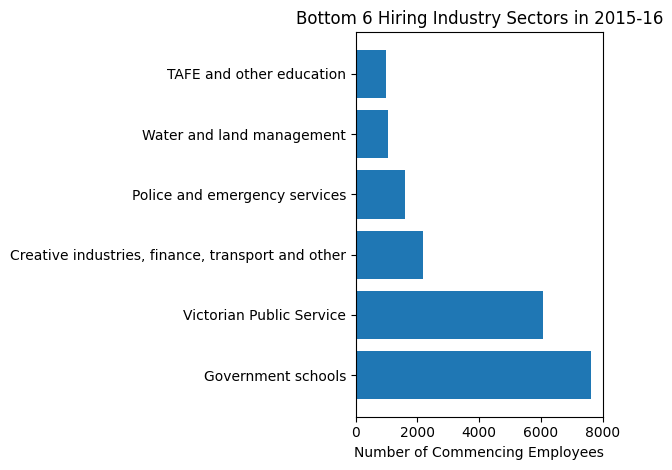

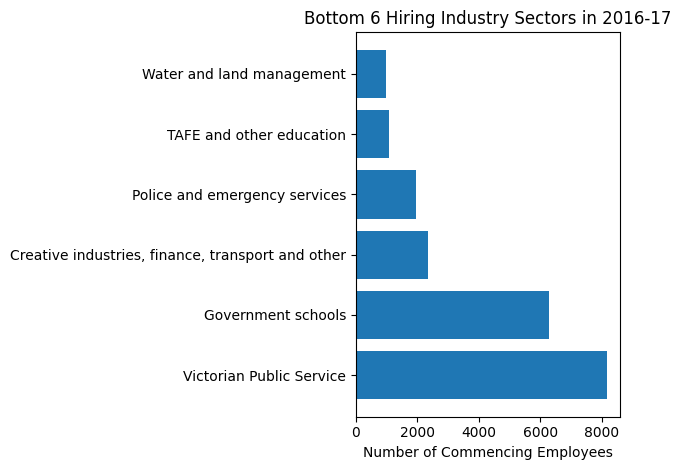

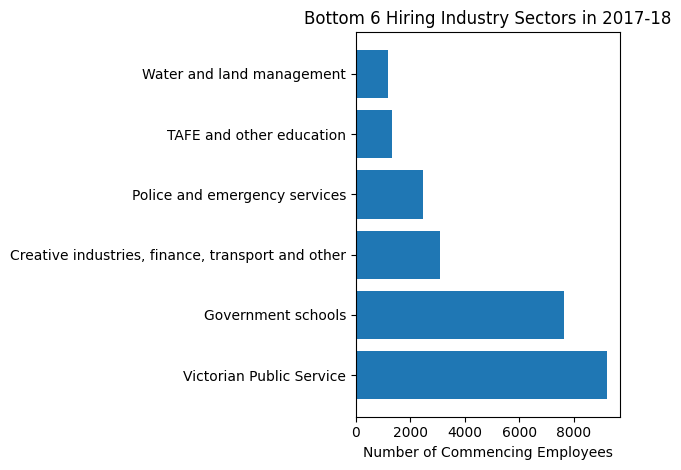

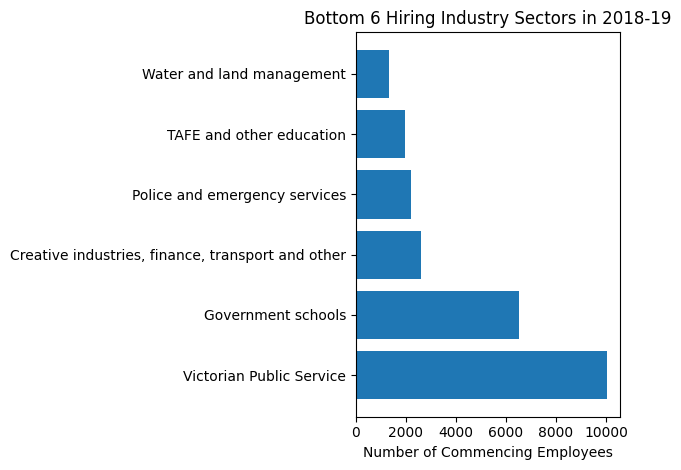

In [15]:
# get bottom N sectors per year
N = 6
for year in year_cols:
    bottom_sectors = commencing_df[['Industry sector', year]].dropna()
    bottom_sectors = bottom_sectors.sort_values(by=year, ascending=True).head(N)
    
    plt.barh(bottom_sectors['Industry sector'], bottom_sectors[year])
    plt.gca().invert_yaxis()
    plt.title(f"Bottom {N} Hiring Industry Sectors in {year}")
    plt.xlabel("Number of Commencing Employees")
    plt.tight_layout()
    plt.show()

Water and land management has performed the worst its the bottom Sector in Number of commencing for All employees (excluding casuals) in 3 years

# New staff rate for All employees (excluding casuals) 

In [16]:
new_staff_df = df[
    (df['Measure'] == 'New staff rate') &
    (df['Group'] == 'All employees (excluding casuals)')
]
new_staff_df.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
3,"Creative industries, finance, transport and other",All employees (excluding casuals),New staff rate,0.11,0.146,0.153,0.183,0.173,0.133,0.159
7,Government schools,All employees (excluding casuals),New staff rate,0.092,0.103,0.084,0.097,0.08,0.058,0.060
11,Police and emergency services,All employees (excluding casuals),New staff rate,0.058,0.062,0.074,0.088,0.075,0.069,0.059
15,Public health care,All employees (excluding casuals),New staff rate,0.137,0.14,0.152,0.152,0.155,0.142,0.157
19,TAFE and other education,All employees (excluding casuals),New staff rate,0.091,0.125,0.134,0.166,0.215,0.133,0.136


In [17]:
new_staff_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 3 to 35
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  9 non-null      object 
 1   Group            9 non-null      object 
 2   Measure          9 non-null      object 
 3   2014-15          9 non-null      object 
 4   2015-16          9 non-null      object 
 5   2016-17          9 non-null      object 
 6   2017-18          9 non-null      object 
 7   2018-19          9 non-null      object 
 8   2019-20          9 non-null      object 
 9   2020-21          9 non-null      float64
dtypes: float64(1), object(9)
memory usage: 792.0+ bytes


In [18]:
# get unique years in data
print("Unique Industry sectors in data:")
new_staff_df['Industry sector'].unique()

Unique Industry sectors in data:


array(['Creative industries, finance, transport and other',
       'Government schools', 'Police and emergency services',
       'Public health care', 'TAFE and other education',
       'Water and land management', 'Total public entities',
       'Victorian Public Service', 'Overall public sector'], dtype=object)

# Top New staff rate for All employees (excluding casuals) 

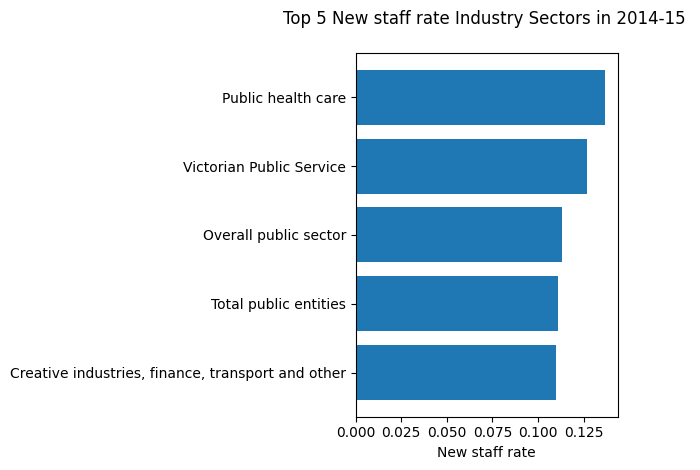

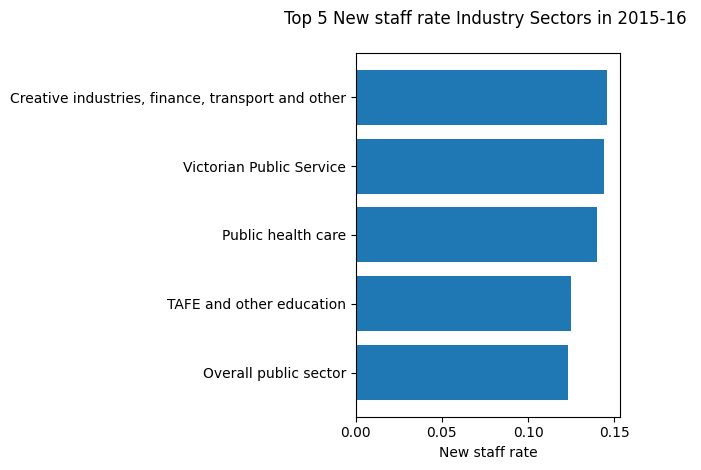

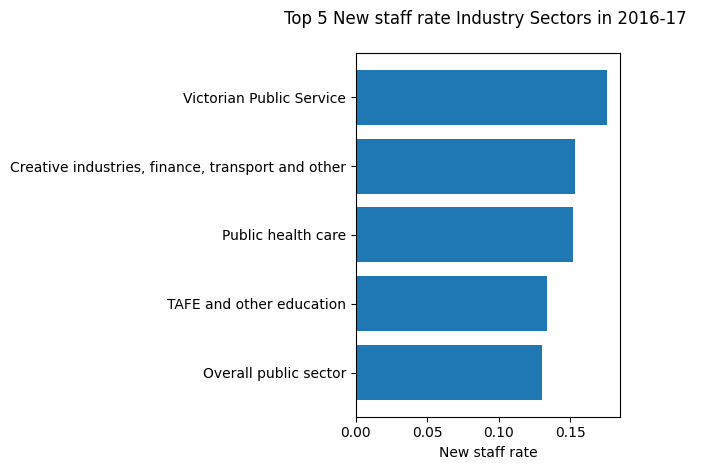

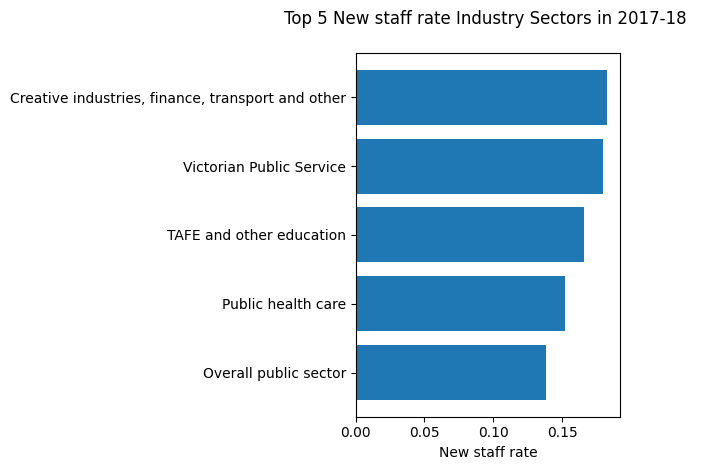

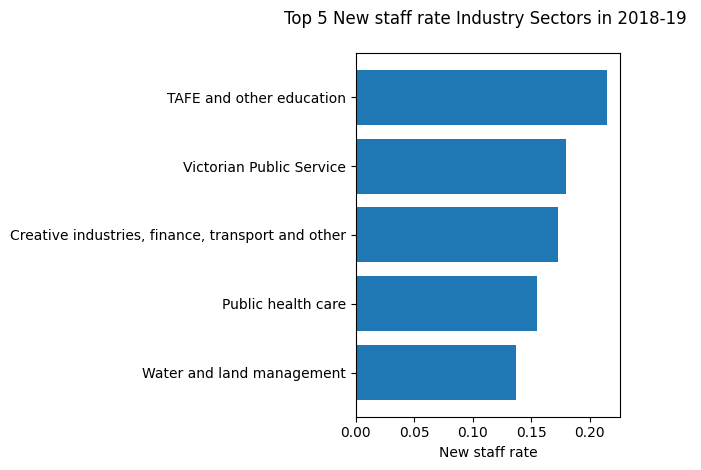

In [19]:
# get N top New staff rate per year
N = 5
for year in year_cols:
    top_sectors = new_staff_df[['Industry sector', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Industry sector'], top_sectors[year])
    plt.title(f"Top {N} New staff rate Industry Sectors in {year} \n")
    plt.xlabel("New staff rate")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Creative industries, finance, transport and other is the top performing sector its has toped twice and general shows high new staff rate

# Bottom New staff rate for All employees (excluding casuals) 

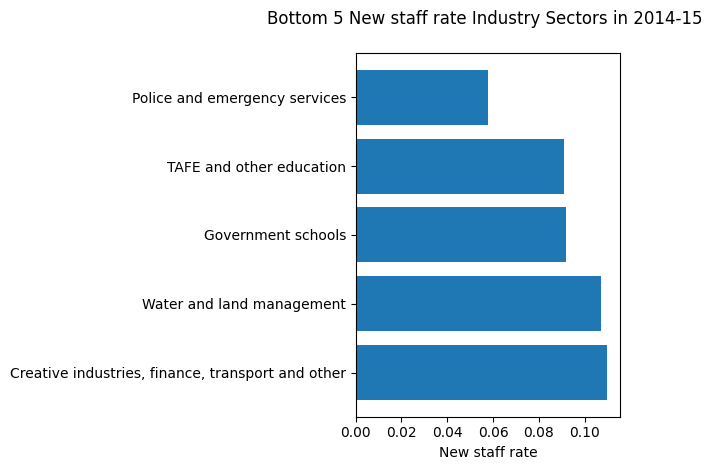

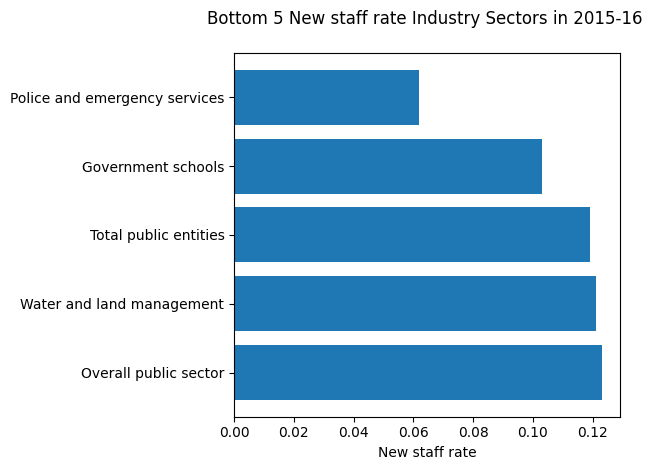

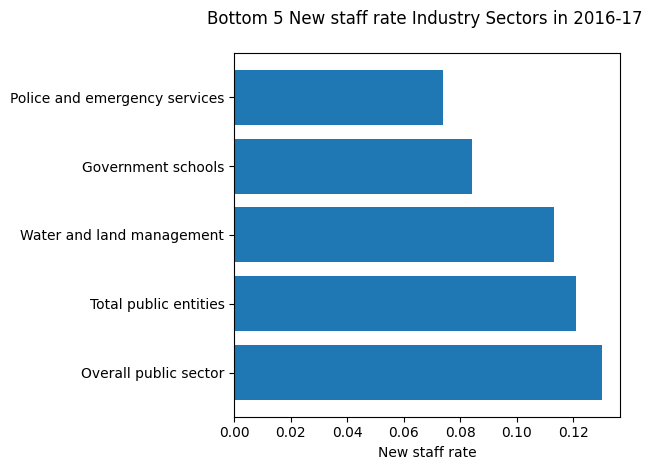

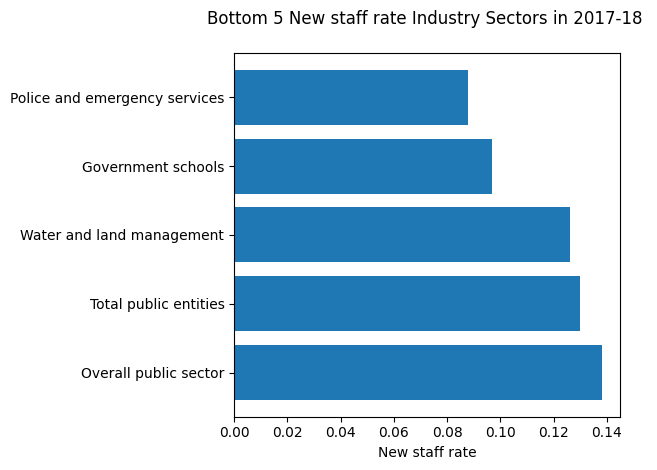

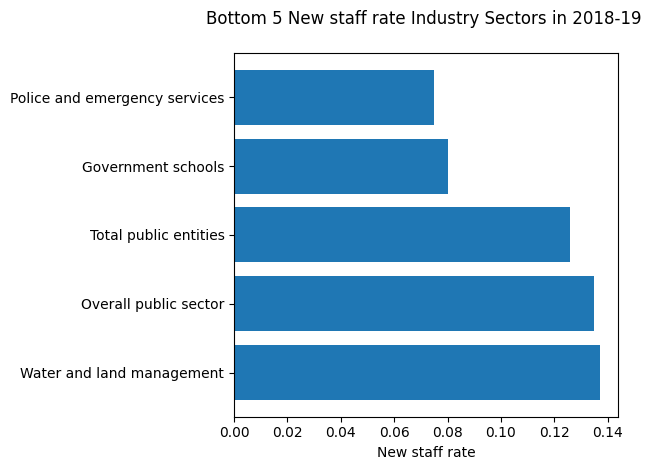

In [20]:
# get N top New staff rate per year
N = 5
for year in year_cols:
    bottom_sectors = new_staff_df[['Industry sector', year]].sort_values(by=year, ascending=True).head(N)

    # horizontal bar plot
    plt.barh(bottom_sectors['Industry sector'], bottom_sectors[year])
    plt.title(f"Bottom {N} New staff rate Industry Sectors in {year} \n")
    plt.xlabel("New staff rate")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Police and emergency services is the worst performing sector across the years in New staff rate 

# Number of separating employees (excluding casuals)

In [21]:
separating_employees = df[
    (df['Measure'] == 'Number of separating employees (excluding casuals)') &
    (df['Group'] == 'All employees (excluding casuals)')
]

In [22]:
separating_employees.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
0,"Creative industries, finance, transport and other",All employees (excluding casuals),Number of separating employees (excluding casu...,1518,1730,1899,2364,2170,1885,1854.0
4,Government schools,All employees (excluding casuals),Number of separating employees (excluding casu...,5790,6328,5428,6160,6808,6755,5653.0
8,Police and emergency services,All employees (excluding casuals),Number of separating employees (excluding casu...,994,1069,977,830,1144,1097,1160.0
12,Public health care,All employees (excluding casuals),Number of separating employees (excluding casu...,12682,13316,13616,14082,14239,14026,15991.0
16,TAFE and other education,All employees (excluding casuals),Number of separating employees (excluding casu...,1475,1244,1158,1166,1259,1294,1199.0


In [23]:
separating_employees.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 0 to 32
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  9 non-null      object 
 1   Group            9 non-null      object 
 2   Measure          9 non-null      object 
 3   2014-15          9 non-null      object 
 4   2015-16          9 non-null      object 
 5   2016-17          9 non-null      object 
 6   2017-18          9 non-null      object 
 7   2018-19          9 non-null      object 
 8   2019-20          9 non-null      object 
 9   2020-21          9 non-null      float64
dtypes: float64(1), object(9)
memory usage: 792.0+ bytes


# Top Number of separating employees (excluding casuals) in All employees (excluding casuals)

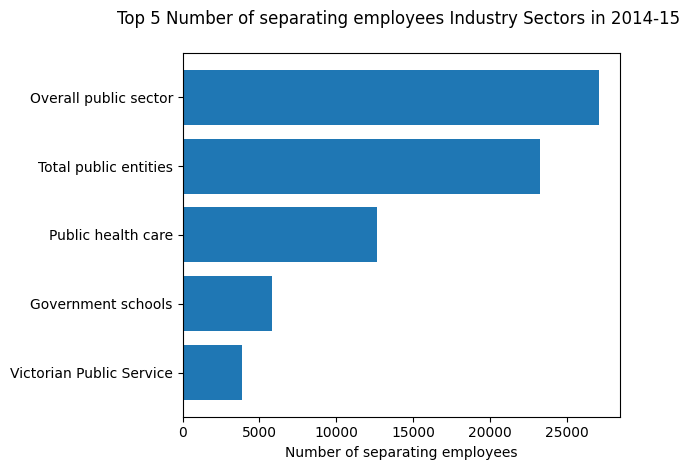

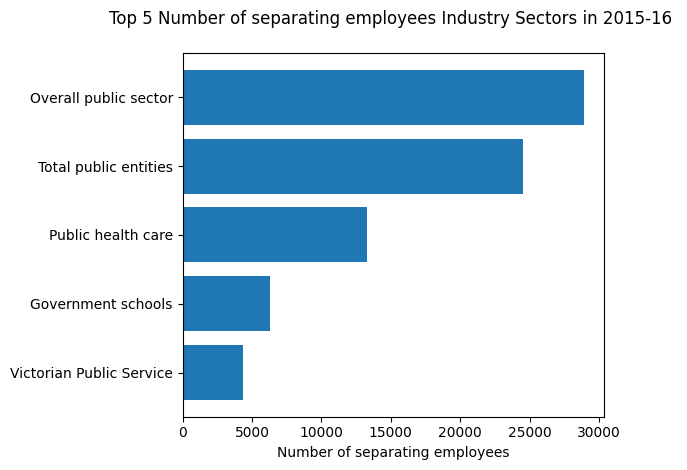

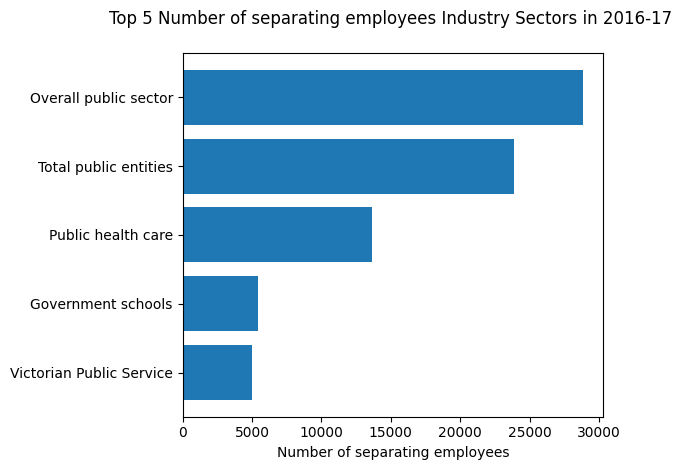

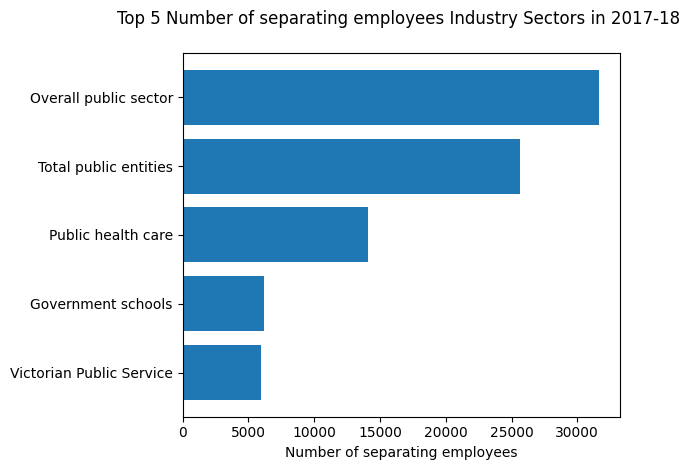

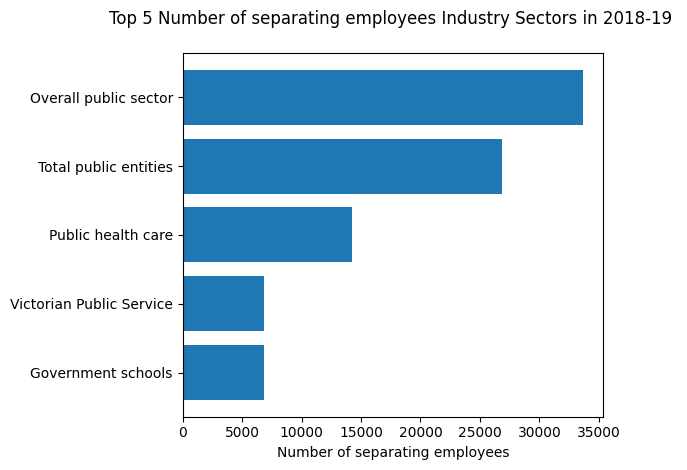

In [24]:
# get N top Number of separating employees
N = 5
for year in year_cols:
    top_sectors = separating_employees[['Industry sector', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Industry sector'], top_sectors[year])
    plt.title(f"Top {N} Number of separating employees Industry Sectors in {year} \n")
    plt.xlabel("Number of separating employees")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Overall public sector is the sector in which most people are separating and also joining / commencing. Most people will join they'll also leave the sector

# Bottom Number of separating employees (excluding casuals) in All employees (excluding casuals)

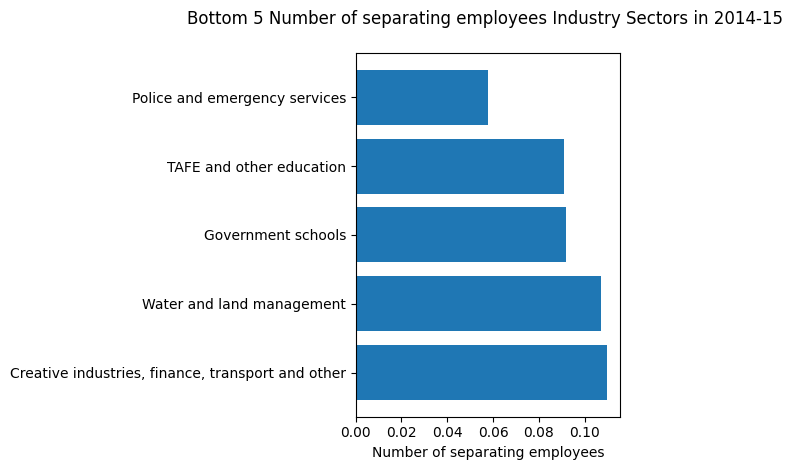

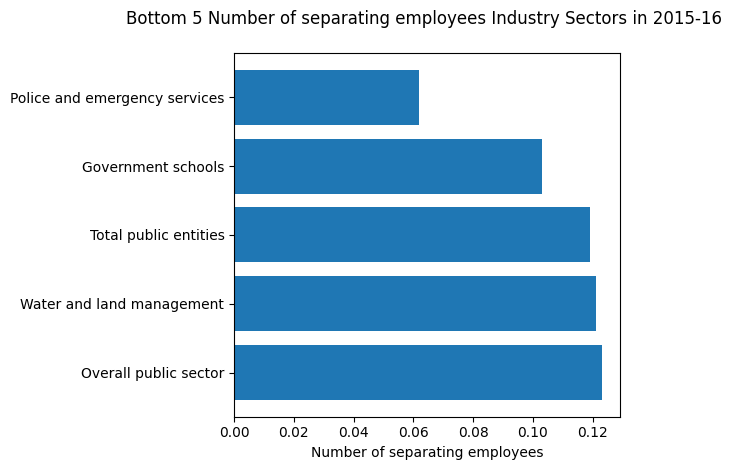

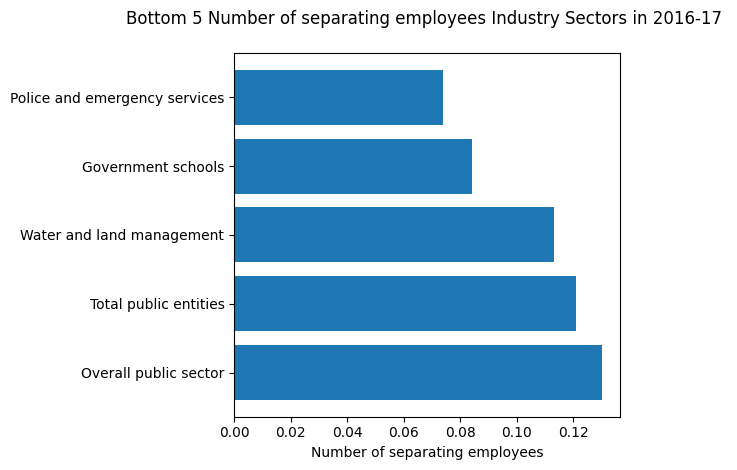

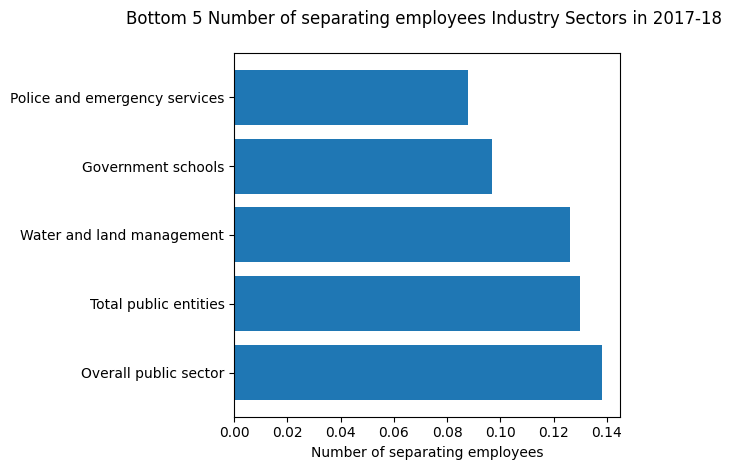

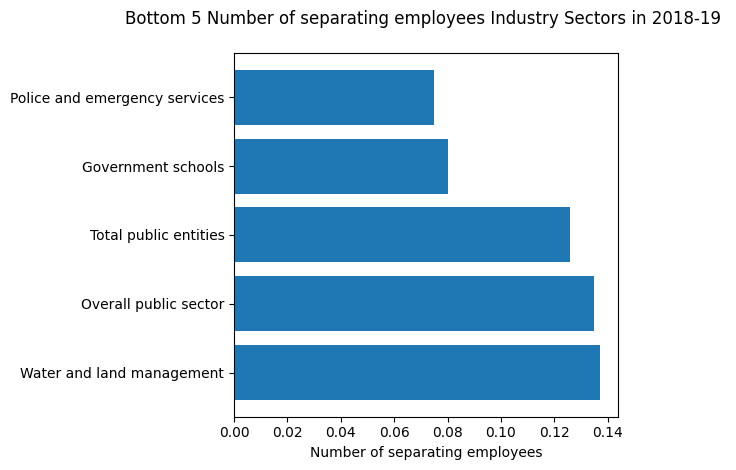

In [25]:
# get N bottom Number of separating employees 
N = 5
for year in year_cols:
    bottom_sectors = new_staff_df[['Industry sector', year]].sort_values(by=year, ascending=True).head(N)

    # horizontal bar plot
    plt.barh(bottom_sectors['Industry sector'], bottom_sectors[year])
    plt.title(f"Bottom {N} Number of separating employees Industry Sectors in {year} \n")
    plt.xlabel("Number of separating employees")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Police and emergency services is the sector with the least number of separating employees despite being the worst performing sector across the years in New staff rate 

# Separation rate

In [26]:
separation_rate = df[
    (df['Measure'] == 'Separation rate') &
    (df['Group'] == 'All employees (excluding casuals)')
]
separation_rate.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
1,"Creative industries, finance, transport and other",All employees (excluding casuals),Separation rate,0.108,0.115,0.123,0.139,0.144,0.121,0.113
5,Government schools,All employees (excluding casuals),Separation rate,0.081,0.085,0.072,0.078,0.083,0.081,0.065
9,Police and emergency services,All employees (excluding casuals),Separation rate,0.04,0.041,0.037,0.03,0.039,0.036,0.037
13,Public health care,All employees (excluding casuals),Separation rate,0.116,0.119,0.118,0.118,0.114,0.108,0.116
17,TAFE and other education,All employees (excluding casuals),Separation rate,0.18,0.156,0.144,0.146,0.137,0.135,0.122


# Top Separation rate per Sector

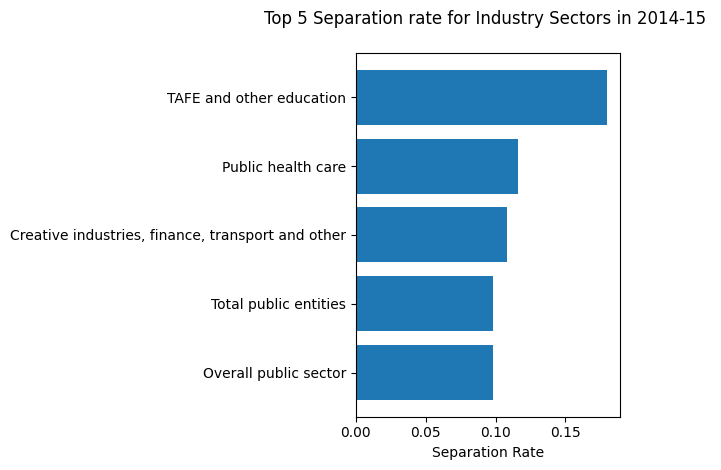

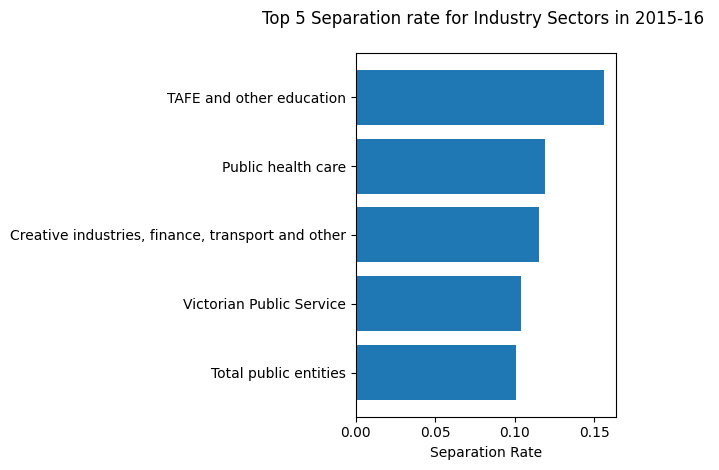

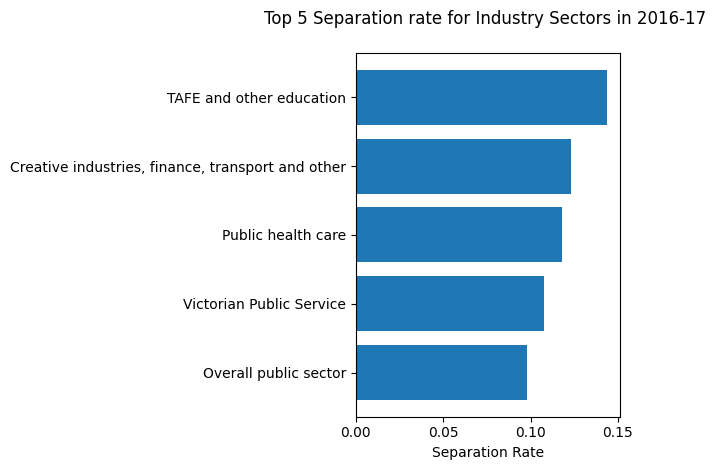

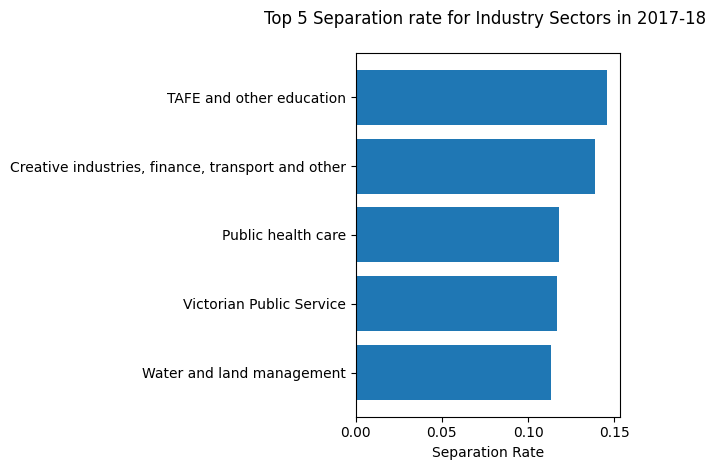

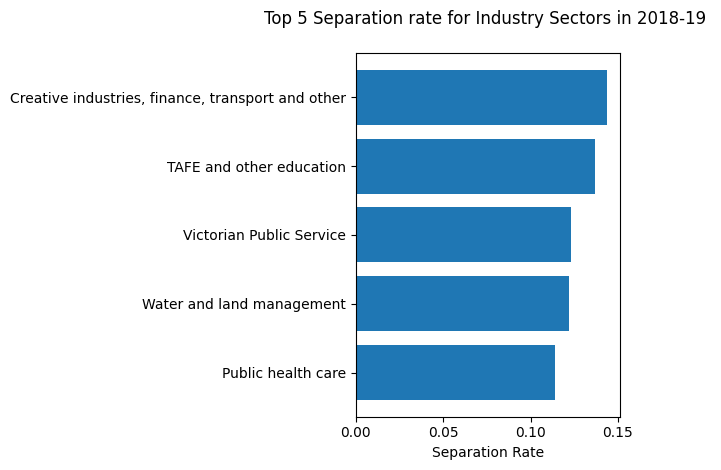

In [27]:
# get N top Top Separation rate
N = 5
for year in year_cols:
    top_sectors = separation_rate[['Industry sector', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Industry sector'], top_sectors[year])
    plt.title(f"Top {N} Separation rate for Industry Sectors in {year} \n")
    plt.xlabel("Separation Rate")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

TAFE and other education is the top sector in separation rates, most people quit / resign / separate with this sector

# Bottom Separation rate

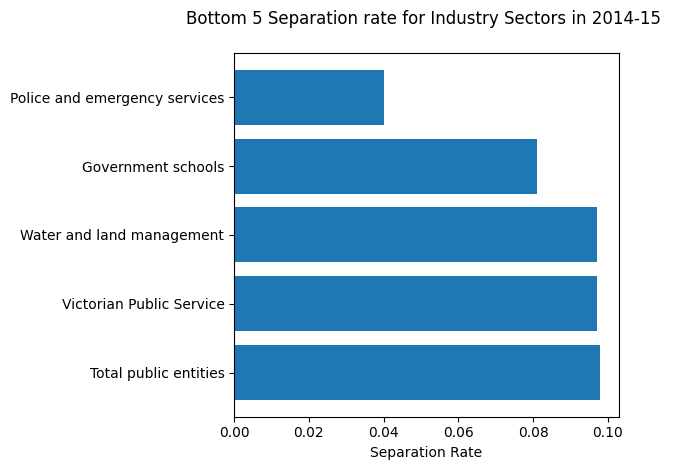

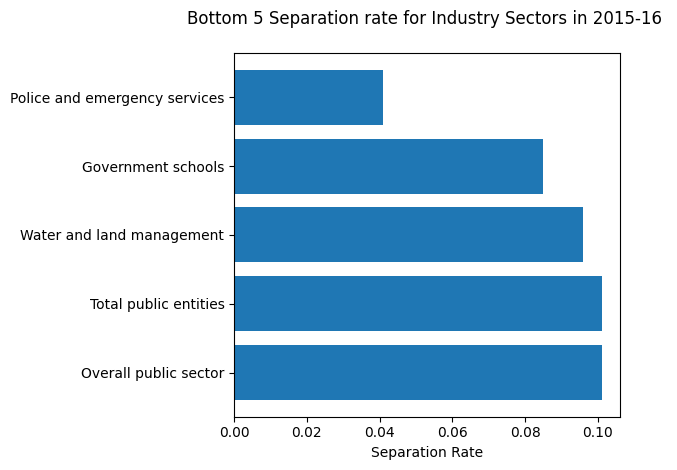

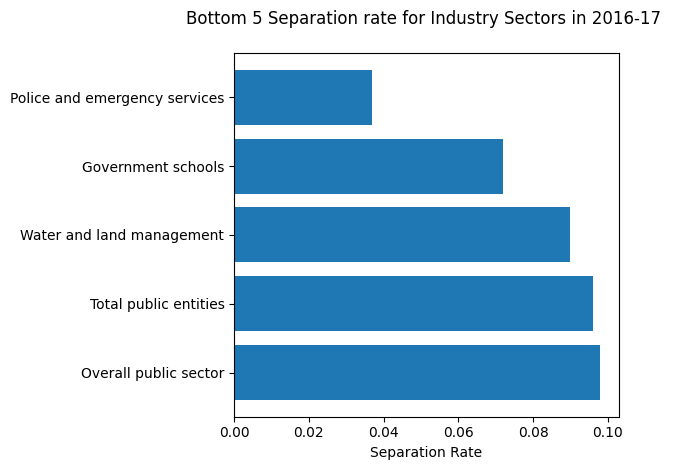

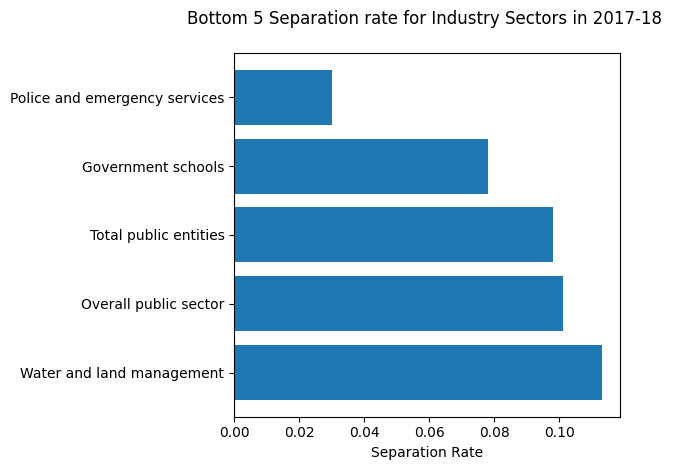

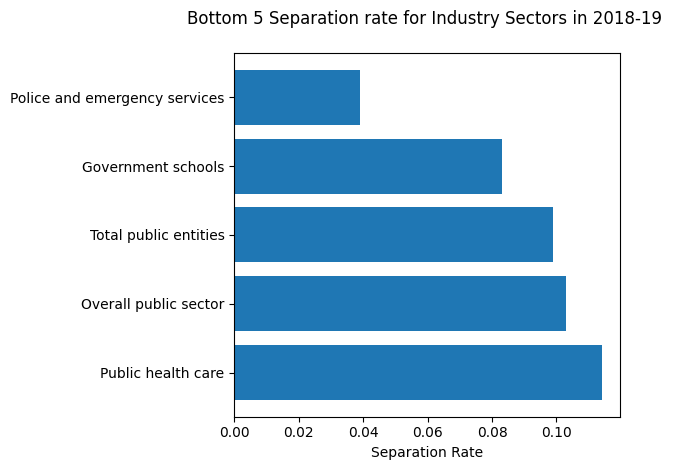

In [28]:
# get N bottom Number of separating employees 
N = 5
for year in year_cols:
    bottom_sectors = separation_rate[['Industry sector', year]].sort_values(by=year, ascending=True).head(N)

    # horizontal bar plot
    plt.barh(bottom_sectors['Industry sector'], bottom_sectors[year])
    plt.title(f"Bottom {N} Separation rate for Industry Sectors in {year} \n")
    plt.xlabel("Separation Rate")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Police and emergency services is the sector with the least number of separation rates & separating employees, Government Schools comes in second with the least number of Separation Rates. People joining Police and emergency services are very likely to remain in the sector without separating / quiting / leaving

# Age group analysis

In [42]:
# remove all All employees for age grouped data
grouped_age_df = df[
    (df['Group'] != 'All employees (excluding casuals)')
]
grouped_age_df.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
36,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,101,109,110,144,134,104,82.000
37,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),Separation rate,0.211,0.233,0.213,0.238,0.264,0.237,0.193
38,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),As a percentage of industry’s separations,0.067,0.063,0.058,0.061,0.062,0.055,0.044
39,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,182,232,250,309,235,165,178.000
40,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),New staff rate,0.38,0.496,0.484,0.51,0.464,0.377,0.419


In [30]:
grouped_age_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 549 entries, 36 to 584
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  549 non-null    object 
 1   Group            546 non-null    object 
 2   Measure          546 non-null    object 
 3   2014-15          544 non-null    object 
 4   2015-16          544 non-null    object 
 5   2016-17          544 non-null    object 
 6   2017-18          544 non-null    object 
 7   2018-19          544 non-null    object 
 8   2019-20          544 non-null    object 
 9   2020-21          546 non-null    float64
dtypes: float64(1), object(9)
memory usage: 47.2+ KB


In [43]:
# get unique groups
grouped_age_df['Group'].unique()

array(['Aged under 25 (excluding casuals)',
       'Aged 25-29 (excluding casuals)', 'Aged 30-34 (excluding casuals)',
       'Aged 35-39 (excluding casuals)', 'Aged 40-44 (excluding casuals)',
       'Aged 45-49 (excluding casuals)', 'Aged 50-54 (excluding casuals)',
       'Aged 55-59 (excluding casuals)', 'Aged 60-64 (excluding casuals)',
       'Aged 65+ (excluding casuals)', 'Aged Missing (excluding casuals)',
       nan], dtype=object)

In [44]:
# remove missing aged data and null values
grouped_age_df = grouped_age_df[
    (grouped_age_df['Group'] != 'Aged Missing (excluding casuals)')
]
grouped_age_df.dropna()
grouped_age_df['Group'].unique()

array(['Aged under 25 (excluding casuals)',
       'Aged 25-29 (excluding casuals)', 'Aged 30-34 (excluding casuals)',
       'Aged 35-39 (excluding casuals)', 'Aged 40-44 (excluding casuals)',
       'Aged 45-49 (excluding casuals)', 'Aged 50-54 (excluding casuals)',
       'Aged 55-59 (excluding casuals)', 'Aged 60-64 (excluding casuals)',
       'Aged 65+ (excluding casuals)', nan], dtype=object)

In [45]:
# remove nan col
grouped_age_df = grouped_age_df.dropna(subset=['Group'])

In [46]:
grouped_age_df['Group'].unique()

array(['Aged under 25 (excluding casuals)',
       'Aged 25-29 (excluding casuals)', 'Aged 30-34 (excluding casuals)',
       'Aged 35-39 (excluding casuals)', 'Aged 40-44 (excluding casuals)',
       'Aged 45-49 (excluding casuals)', 'Aged 50-54 (excluding casuals)',
       'Aged 55-59 (excluding casuals)', 'Aged 60-64 (excluding casuals)',
       'Aged 65+ (excluding casuals)'], dtype=object)

# Number of commencing employees (excluding casuals) by age groups

In [50]:
# get Number of commencing employees
commencing_grouped = grouped_age_df[
    (grouped_age_df['Measure'] == 'Number of commencing employees (excluding casuals)') 
]
commencing_grouped.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
39,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,182,232,250,309,235,165,178.0
45,Government schools,Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,1619,1722,1549,1959,1377,1236,1406.0
51,Police and emergency services,Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,315,328,506,588,547,433,355.0
57,Public health care,Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,2677,2744,2984,3085,3316,3080,4560.0
63,TAFE and other education,Aged under 25 (excluding casuals),Number of commencing employees (excluding casu...,57,68,66,86,102,77,141.0


In [51]:
commencing_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 39 to 579
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Industry sector  90 non-null     object 
 1   Group            90 non-null     object 
 2   Measure          90 non-null     object 
 3   2014-15          90 non-null     object 
 4   2015-16          90 non-null     object 
 5   2016-17          90 non-null     object 
 6   2017-18          90 non-null     object 
 7   2018-19          90 non-null     object 
 8   2019-20          90 non-null     object 
 9   2020-21          90 non-null     float64
dtypes: float64(1), object(9)
memory usage: 7.7+ KB


In [52]:
# group by age groups to get sum 
commencing_grouped_sep = commencing_grouped.groupby('Group')[year_cols].sum().reset_index()
commencing_grouped_sep.head()

,Group,2014-15,2015-16,2016-17,2017-18,2018-19
0,Aged 25-29 (excluding casuals),21635,24740,26234,28793,28686
1,Aged 30-34 (excluding casuals),14993,17004,18738,21240,22515
2,Aged 35-39 (excluding casuals),10562,12057,13052,14798,15274
3,Aged 40-44 (excluding casuals),8382,9448,10633,11308,11621
4,Aged 45-49 (excluding casuals),6471,7705,8180,9458,9352


In [56]:
commencing_grouped_sep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Group    10 non-null     object
 1   2014-15  10 non-null     object
 2   2015-16  10 non-null     object
 3   2016-17  10 non-null     object
 4   2017-18  10 non-null     object
 5   2018-19  10 non-null     object
dtypes: object(6)
memory usage: 612.0+ bytes


# Top Number of commencing employees (excluding casuals) by age groups

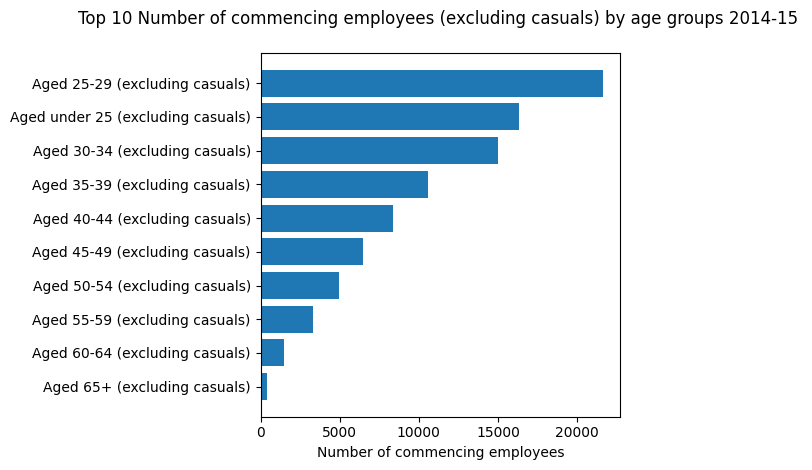

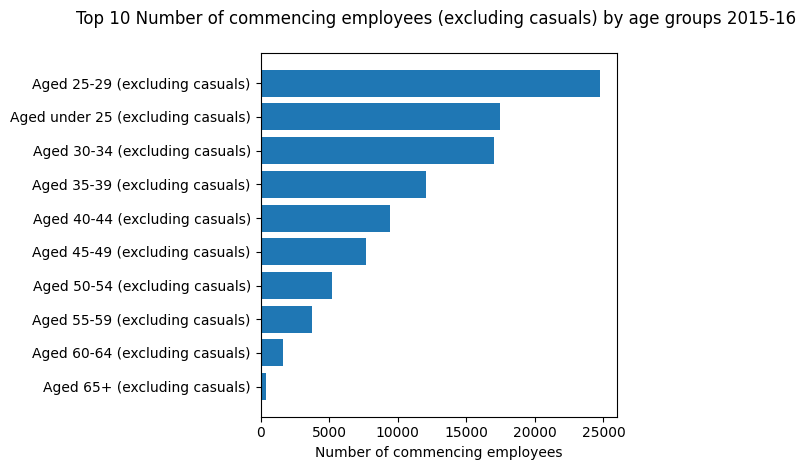

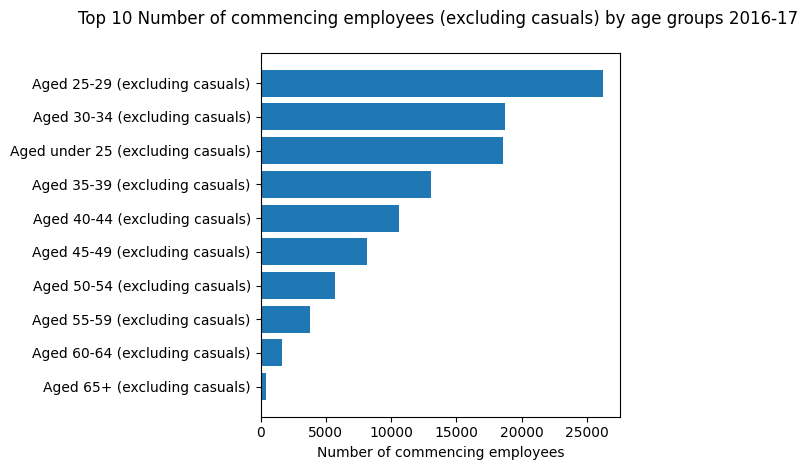

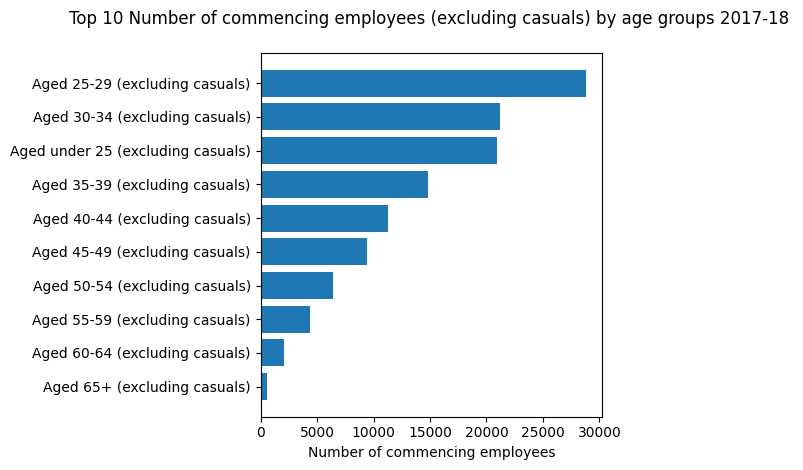

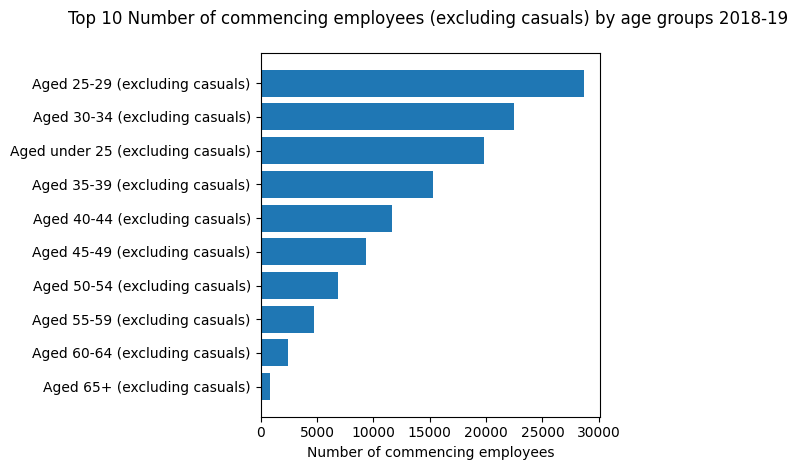

In [59]:
N = 10
for year in year_cols:
    top_sectors = commencing_grouped_sep[['Group', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Group'], top_sectors[year])
    plt.title(f"Top {N} Number of commencing employees (excluding casuals) by age groups {year} \n")
    plt.xlabel("Number of commencing employees")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Aged 25-29 (excluding casuals) is the age group that has the most Number of commencing employees. As the age grows, except for Aged under 25 (excluding casuals) the number drops, meaning older age groups are less likely to be  commencing employees.

# Number of separating employees (excluding casuals) by age group

In [61]:
# filter by Number of separating employees
separating_employees = grouped_age_df[
    (grouped_age_df['Measure'] == 'Number of separating employees (excluding casuals)') 
]
separating_employees.head()

,Industry sector,Group,Measure,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21
36,"Creative industries, finance, transport and other",Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,101,109,110,144,134,104,82.0
42,Government schools,Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,318,261,293,267,349,323,292.0
48,Police and emergency services,Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,26,24,35,36,39,35,35.0
54,Public health care,Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,920,884,834,859,881,830,1100.0
60,TAFE and other education,Aged under 25 (excluding casuals),Number of separating employees (excluding casu...,57,38,36,30,47,48,37.0


In [63]:
# group by age groups to get sum 
separating_employees_sep = separating_employees.groupby('Group')[year_cols].sum().reset_index()
separating_employees_sep

,Group,2014-15,2015-16,2016-17,2017-18,2018-19
0,Aged 25-29 (excluding casuals),13559,14648,14606,14847,15673
1,Aged 30-34 (excluding casuals),12762,13535,13295,15065,15557
2,Aged 35-39 (excluding casuals),9104,10002,9835,11378,11722
3,Aged 40-44 (excluding casuals),7098,7601,7661,8680,9280
4,Aged 45-49 (excluding casuals),6026,6412,6890,7689,8116
5,Aged 50-54 (excluding casuals),5488,6095,5735,6072,6675
6,Aged 55-59 (excluding casuals),6920,6876,6268,6516,6931
7,Aged 60-64 (excluding casuals),6291,6967,7044,7616,7996
8,Aged 65+ (excluding casuals),5203,5311,5511,6063,6564
9,Aged under 25 (excluding casuals),5038,4843,4794,5066,5655


# Top Number of separating employees (excluding casuals) by age group

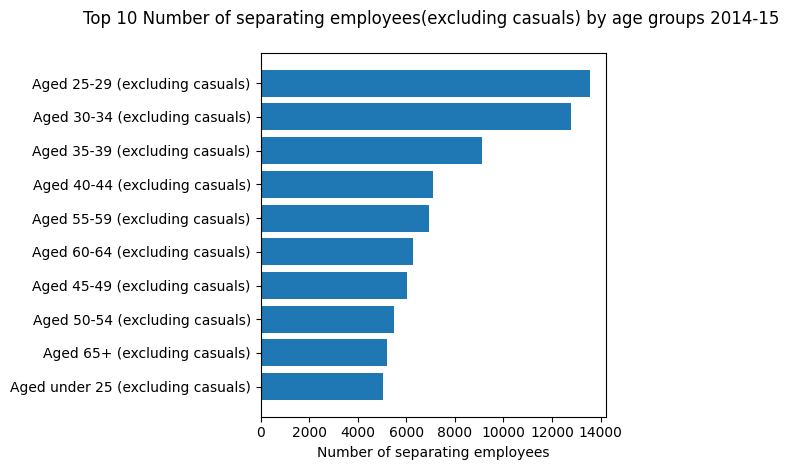

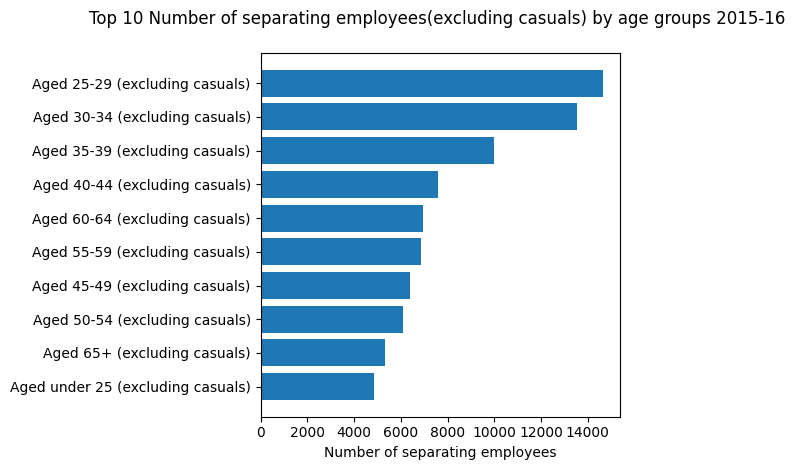

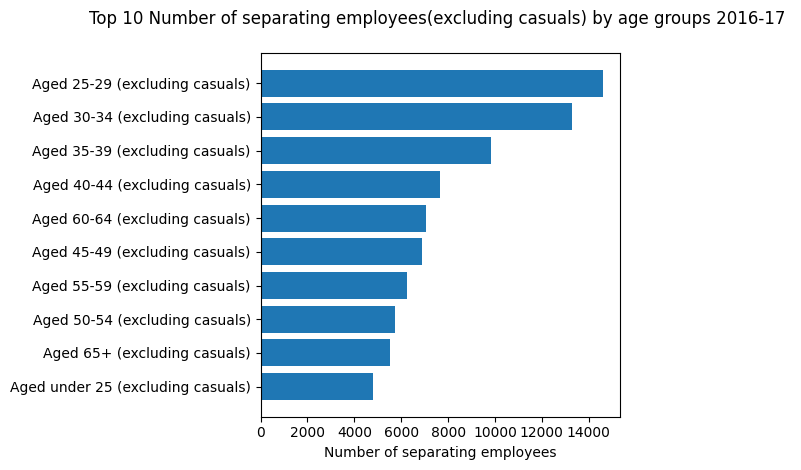

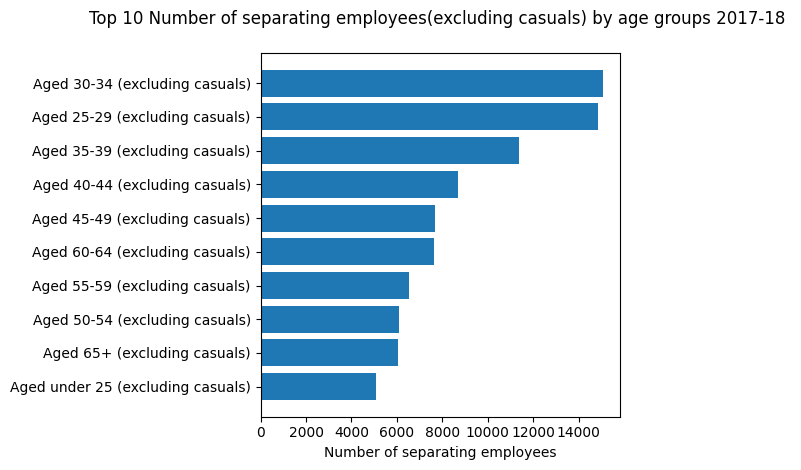

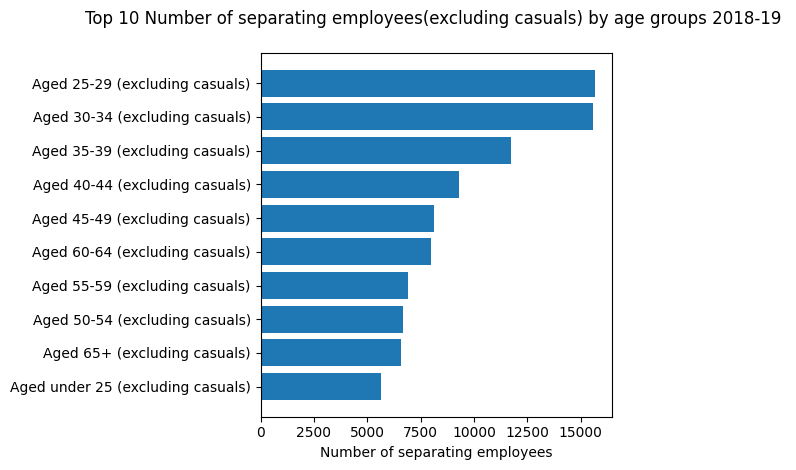

In [64]:
N = 10
for year in year_cols:
    top_sectors = separating_employees_sep[['Group', year]].sort_values(by=year, ascending=False).head(N)

    # horizontal bar plot
    plt.barh(top_sectors['Group'], top_sectors[year])
    plt.title(f"Top {N} Number of separating employees(excluding casuals) by age groups {year} \n")
    plt.xlabel("Number of separating employees")

    # highest at top
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Aged 25-29 (excluding casuals) is top next is Aged 30-34 (excluding casuals) in top age groups with highest Number of separating employees. This shows that this age groups are willing to separate from their various sectors. while Aged 25-29 (excluding casuals)is the least likely to do so.